In [2]:
import pandas as pd 
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
import os
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [3]:
# tarsal result 
fpath = f'data/each_leg_sex.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_tarsal = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_tarsal[s] = df
    
mean_df_fig = pd.DataFrame(index=sheets,columns=['foreleg','midleg','hindleg'])
std_df_fig = pd.DataFrame(index=sheets,columns=['foreleg','midleg','hindleg'])
for i,df in data_df_tarsal.items():
    mean_df_fig.loc[i] = df.mean()
    std_df_fig.loc[i] = std_err(df)
mean_df_fig = mean_df_fig.transpose()
std_df_fig = std_df_fig.transpose()

In [4]:
# from scipy.stats import kruskal,dunnett
# vals = [list(data_df_tarsal['Female'][x]) for x in data_df_tarsal['Female'].keys()]
# kru = kruskal(*vals)
# # print('Kruskal Wallis test pval',concent,kru.pvalue)
# dunn = dunnett(*[data_df_tarsal['Female'][x] for x in ['midleg','hindleg']],control=data_df_tarsal['Female']['foreleg'])
# print("Dunnet's test pval",dunn.pvalue)

Dunnet's test pval [5.63427474e-05 4.47129136e-08]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

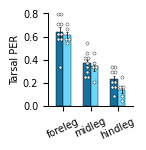

In [6]:
######### figure C
fig,ax = plt.subplots(1,1,figsize=(1.1,1.2))


ax = draw_paired_bar_figure(
    data=data_df_tarsal,
    mean_df=mean_df_fig,
    err_df=std_df_fig,
    bar_width = 0.2,
    bar_spacing=.7,
    stat_fontsize = 7,
    fontsize=7,
    dot_size=5,
    capsize=1,
    linewidth=.3,
    ax=ax,
    conds=['foreleg','midleg','hindleg'],
    groups=['Female', 'Male'],
    get_values=lambda data, cond, group: data[group][cond],
    stat_pairs=None,#,[
#         (('foreleg', 'Female'), ('midleg', 'Female')),
#         (('foreleg', 'Female'), ('hindleg', 'Female')),
#         (('hindleg', 'Female'), ('hindleg', 'Male'))
#    ],
    colors= ['#13739E','#6DD6F9'],
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.split('>')[0],
    ylim=(0, .8),
    yticks=np.round(np.arange(0, .81, .2), 2)
)
ax.tick_params('x',rotation=25)
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
# plt.savefig('per_leg_exp.svg')



In [9]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

female = data_df_tarsal['Female']

# ---------- Friedman test ----------
stat, p = friedmanchisquare(
    female['foreleg'],
    female['midleg'],
    female['hindleg']
)

print(f'Friedman: chi2={stat:.3f}, p={p:.5f}')

# ---------- Pairwise Wilcoxon signed-rank ----------
comparisons = [
    ('foreleg', 'midleg'),
    ('foreleg', 'hindleg'),
    ('midleg', 'hindleg')
]

results = []

for g1, g2 in comparisons:
    stat, p = wilcoxon(
        female[g1],
        female[g2],
        alternative='greater',
    )
    results.append([g1, g2, stat, p])

result_df = pd.DataFrame(
    results,
    columns=['Group1', 'Group2', 'W', 'raw_p']
)

# Holm correction
result_df['holm_p'] = multipletests(
    result_df['raw_p'],
    method='holm'
)[1]

print(result_df)

Friedman: chi2=13.771, p=0.00102
    Group1   Group2     W     raw_p    holm_p
0  foreleg   midleg  44.0  0.003906  0.007812
1  foreleg  hindleg  45.0  0.001953  0.005859
2   midleg  hindleg  35.0  0.008645  0.008645


/home/se/anaconda3/envs/flywire/lib/python3.9/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
